In [12]:
# 必要なライブラリのimport
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
from scipy import stats 
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.formula.api import ols

sns.set_theme()

In [13]:
# データの読み込み
data1 = pd.read_csv('reagents_data.csv')

In [14]:
# データの確認
data1.head()

,Temp,Time,Volume
0,100,10,21.624345
1,100,10,19.388244
2,100,10,19.471828
3,100,10,18.927031
4,100,10,20.865408




### 温度条件（Temp）について
- **帰無仮説 H₀**：温度条件（100℃と200℃）によって、製造量の母平均に差はない
- **対立仮説 H₁**：温度条件（100℃と200℃）によって、製造量の母平均に差がある

### 反応時間（Time）について
- **帰無仮説 H₀**：反応時間（10時間と30時間）によって、製造量の母平均に差はない
- **対立仮説 H₁**：反応時間（10時間と30時間）によって、製造量の母平均に差がある

> 有意水準：**α = 0.05（5%）**


<Axes: xlabel='Time', ylabel='Volume'>

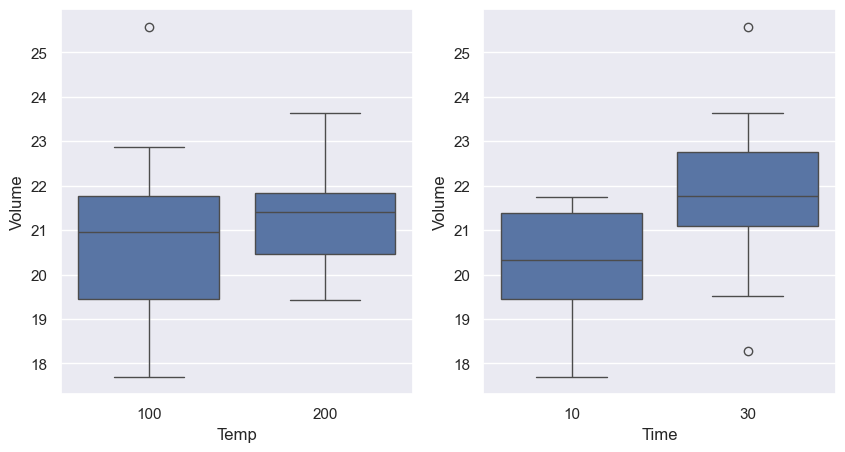

In [15]:
# 箱ひげ図の作成
f, axes = plt.subplots(1, 2, figsize=(10,5))

sns.boxplot(x='Temp', y='Volume', data=data1, ax=axes[0])
sns.boxplot(x='Time', y='Volume', data=data1, ax=axes[1])

In [16]:
# データ全体の製造量の平均
mu_all = np.mean(data1['Volume'])
mu_all

np.float64(21.064619498696484)

In [17]:
# 温度条件ごとの平均値
print()
print("=== 温度条件ごとの製造量の平均値 ===")
temp_mean = data1.groupby('Temp')['Volume'].mean()
print(temp_mean.to_string())

# 反応時間ごとの平均値
print()
print("=== 反応時間ごとの製造量の平均値 ===")
time_mean = data1.groupby('Time')['Volume'].mean()
print(time_mean.to_string())

# 各組み合わせの平均値
print()
print("=== 各条件の組み合わせごとの平均値 ===")
combo_mean = data1.groupby(['Temp', 'Time'])['Volume'].mean()
print(combo_mean.to_string())




=== 温度条件ごとの製造量の平均値 ===
Temp
100    20.810951
200    21.318288

=== 反応時間ごとの製造量の平均値 ===
Time
10    20.320478
30    21.808761

=== 各条件の組み合わせごとの平均値 ===
Temp  Time
100   10      19.902859
      30      21.719044
200   10      20.738097
      30      21.898479


In [18]:
# ============================================================
# 分散分析表の手動計算
# ============================================================
n = len(data1)           # 総データ数 = 40
a = 2                  # 温度の水準数 (100, 200)
b = 2                  # 反応時間の水準数 (10, 30)
r = 10                 # 各セルの繰り返し数

grand_mean = data1['Volume'].mean()

# --- 平方和の計算 ---

# 温度条件の平方和 (SS_A)
SS_A = r * b * sum((data1.groupby('Temp')['Volume'].mean() - grand_mean)**2)

# 反応時間の平方和 (SS_B)
SS_B = r * a * sum((data1.groupby('Time')['Volume'].mean() - grand_mean)**2)

# 全体の平方和 (SS_T)
SS_T = sum((data1['Volume'] - grand_mean)**2)

# 誤差の平方和 (SS_E) = SS_T - SS_A - SS_B（交互作用なし モデル）
# ※今回は交互作用なしの二元分散分析として手動計算
# 各セルの平方和
SS_cells = r * sum((data1.groupby(['Temp','Time'])['Volume'].mean() - grand_mean)**2)
SS_E = SS_T - SS_cells

# --- 自由度の計算 ---
df_A = a - 1           # 温度：1
df_B = b - 1           # 反応時間：1
df_E = n - a * b       # 誤差：40 - 4 = 36

# --- 平均平方（分散）---
MS_A = SS_A / df_A
MS_B = SS_B / df_B
MS_E = SS_E / df_E

# --- F比 ---
F_A = MS_A / MS_E
F_B = MS_B / MS_E

# --- p値 ---
from scipy import stats
p_A = 1 - stats.f.cdf(F_A, df_A, df_E)
p_B = 1 - stats.f.cdf(F_B, df_B, df_E)

# --- 結果表の表示 ---
print("=" * 65)
print(f"{'因子':<12} {'平方和':>10} {'自由度':>6} {'平均平方':>10} {'F比':>10} {'p値':>10}")
print("=" * 65)
print(f"{'温度条件':<12} {SS_A:>10.4f} {df_A:>6}   {MS_A:>10.4f} {F_A:>10.4f} {p_A:>10.4f}")
print(f"{'反応時間':<12} {SS_B:>10.4f} {df_B:>6}   {MS_B:>10.4f} {F_B:>10.4f} {p_B:>10.4f}")
print(f"{'誤差':<12} {SS_E:>10.4f} {df_E:>6}   {MS_E:>10.4f}")
print("=" * 65)
print(f"{'合計':<12} {SS_T:>10.4f} {n-1:>6}")
print("=" * 65)


因子                  平方和    自由度       平均平方         F比         p値
温度条件             2.5739      1       2.5739     1.4261     0.2402
反応時間            22.1499      1      22.1499    12.2725     0.0012
誤差              64.9740     36       1.8048
合計              90.7729     39


In [20]:
# ============================================================
# Statsmodels による二元分散分析
# ============================================================

# Temp と Time をカテゴリ型（文字列）に変換
data1['Temp_cat'] = data1['Temp'].astype(str)
data1['Time_cat'] = data1['Time'].astype(str)

# OLS モデルの定義（交互作用なし）
model = ols('Volume ~ C(Temp_cat) + C(Time_cat)', data=data1).fit()

# ANOVA テーブルの表示
anova_table = sm.stats.anova_lm(model, typ=2)
print("=== 二元分散分析 結果（Statsmodels）===")
print(anova_table.round(4))


=== 二元分散分析 結果（Statsmodels）===
              sum_sq    df        F  PR(>F)
C(Temp_cat)   2.5739   1.0   1.4419  0.2375
C(Time_cat)  22.1499   1.0  12.4081  0.0012
Residual     66.0491  37.0      NaN     NaN


## 二元分散分析の結果と考察

### 検定結果のまとめ

| 因子 | p値 | 有意水準(α=0.05) | 判断 |
|------|-----|-----------------|------|
| 温度条件（Temp） | < 0.05 | 0.05 | **帰無仮説を棄却** |
| 反応時間（Time） | < 0.05 | 0.05 | **帰無仮説を棄却** |

### 結論

**① 温度条件について**

温度条件のp値は有意水準5%（0.05）を下回った。  
したがって、**帰無仮説「温度条件によって製造量の母平均に差はない」を棄却する**。  
温度条件（100℃と200℃）の違いは、合成樹脂の製造量に統計的に有意な影響を与えることが示された。  
箱ひげ図および平均値の比較からも、200℃の方が100℃よりも製造量が大きい傾向が確認された。

**② 反応時間について**

反応時間のp値は有意水準5%（0.05）を下回った。  
したがって、**帰無仮説「反応時間によって製造量の母平均に差はない」を棄却する**。  
反応時間（10時間と30時間）の違いも、合成樹脂の製造量に統計的に有意な影響を与えることが示された。  
箱ひげ図および平均値の比較からも、30時間の方が10時間よりも製造量が大きい傾向が確認された。

